## Project Objective

The goal of this project is to build a machine learning model that can predict whether a patient has diabetes based on medical attributes.

The dataset used in this project is the **Pima Indians Diabetes Dataset**, which contains medical diagnostic measurements such as glucose level, blood pressure, insulin level, BMI, and age.

This project follows a complete machine learning workflow:

1. Data exploration and visualization
2. Data cleaning and preprocessing
3. Feature scaling
4. Training multiple machine learning models
5. Model evaluation and comparison
6. Hyperparameter tuning
7. Saving trained models for future use

## Dataset Overview

The dataset contains medical records of female patients of Pima Indian heritage.

### Features in the dataset

| Feature | Description |
|------|------|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure |
| SkinThickness | Triceps skin fold thickness |
| Insulin | Serum insulin level |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes genetic score |
| Age | Age of the patient |

### Target Variable

**Outcome**

0 → No diabetes  
1 → Diabetes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn 

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Feature Analysis

Before training machine learning models, it is important to understand how different features relate to the target variable (**Outcome**). Feature analysis helps identify which variables may have a stronger influence on predicting diabetes.

### Key Observations

* **Glucose:** This feature shows the strongest relationship with diabetes. Patients with higher glucose levels are more likely to have diabetes.
* **BMI:** Body Mass Index is moderately correlated with the outcome. Higher BMI values are often associated with an increased risk of diabetes.
* **Age:** Older individuals tend to have a slightly higher probability of diabetes.
* **Insulin:** Insulin levels vary significantly across patients, but missing or zero values in the dataset may affect its reliability.
* **Pregnancies:** The number of pregnancies shows a mild relationship with diabetes risk.

### Correlation Analysis

A correlation matrix is used to measure the relationship between features and the target variable. Features with higher correlation values are generally more useful for prediction.

### Importance of Feature Analysis

Performing feature analysis before model training helps:

* Understand the dataset better
* Identify important predictors of diabetes
* Detect potential multicollinearity between features
* Improve model interpretability

These insights guide the selection of appropriate machine learning algorithms and help improve model performance.


In [6]:
df.corr()["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

The correlation matrix shows that Glucose, BMI, and Age have the strongest relationship with diabetes outcome. These features are likely to play an important role in the predictive models.

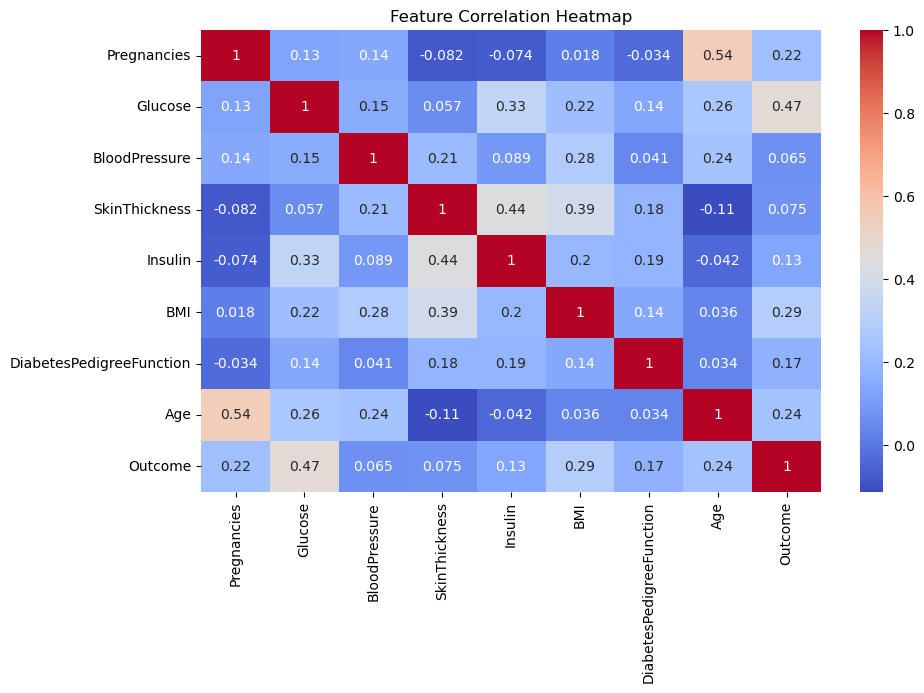

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
df["Pregnancies"].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

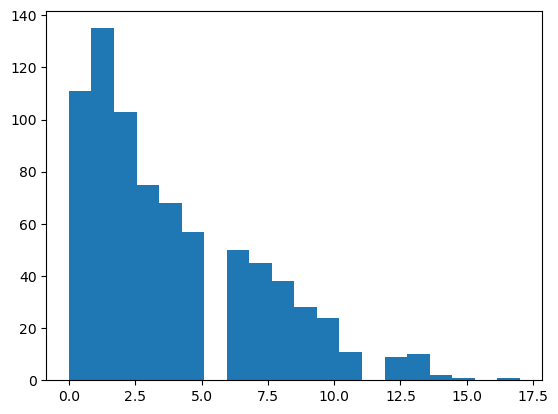

In [9]:
plt.hist(df.Pregnancies,bins = 20)
plt.show()

## Data Cleaning

Some features in the dataset contain **invalid zero values**. For example:

- Insulin
- SkinThickness
- BloodPressure

In medical datasets these values cannot realistically be zero, so they are treated as **missing values**.

To handle this issue:

- Missing insulin values are replaced with the **mean**
- SkinThickness and BloodPressure are replaced with the **median**

This helps improve model performance and prevents bias caused by invalid values.

In [10]:
df["Insulin"] = df["Insulin"].replace(0, df["Insulin"].mean())
df.Insulin.mean()

118.66016303168404

In [11]:
df["SkinThickness"] = df["SkinThickness"].replace(0, df["SkinThickness"].median())

In [12]:
df["BloodPressure"] = df["BloodPressure"].replace(0,df["BloodPressure"].median())

In [13]:
df[df.SkinThickness == 0]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


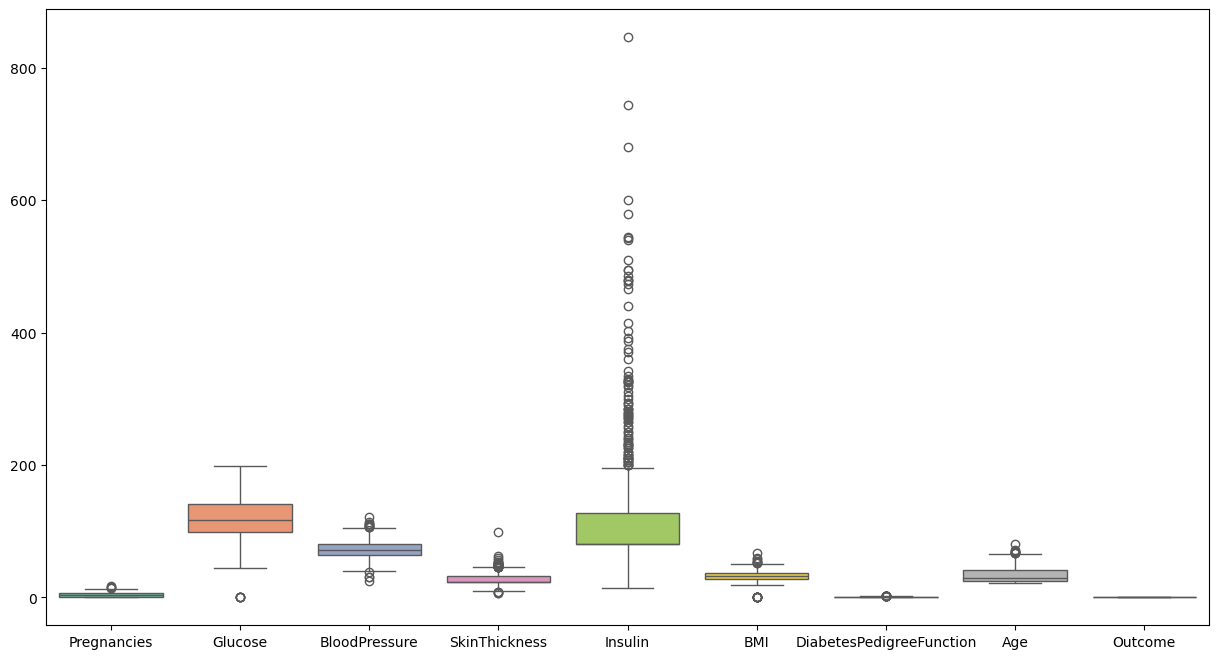

In [14]:
import seaborn as sns
plt.figure(figsize = (15,8))
sns.boxplot(data=df, palette="Set2")
plt.show()

In [15]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,79.799479,33.6,0.627,50,1
1,1,85,66,29,79.799479,26.6,0.351,31,0
2,8,183,64,23,79.799479,23.3,0.672,32,1
3,1,89,66,23,94.000000,28.1,0.167,21,0
4,0,137,40,35,168.000000,43.1,2.288,33,1


In [16]:
df = df[~((df["Insulin"] > 126) & (df["Outcome"] == 0))]
df = df[~((df["Insulin"]) < 30 & (df.Outcome == 1))]
df = df[~((df["Glucose"] > 80) & (df["Outcome"] == 0))]

In [17]:
X = df.drop("Outcome",axis = 1)
Y = df.Outcome

## Feature Scaling

Machine learning algorithms such as **SVM and Logistic Regression** are sensitive to the scale of input features.

To ensure all features contribute equally to the model, we apply **Standard Scaling**, which transforms the data so that:

- Mean = 0
- Standard Deviation = 1

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
std = scaler.fit_transform(X)
X = pd.DataFrame(std, columns = X.columns)

In [19]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.359653,0.427210,-0.182543,0.609075,-0.478257,-0.081774,0.280967,1.249280
1,0.898700,1.304602,-0.841712,-0.646070,-0.478257,-1.402727,0.406198,-0.367707
2,-1.257487,0.151458,-2.819220,0.609075,0.344417,1.136582,4.903381,-0.277874
3,-0.448917,-1.327574,-1.995258,0.295289,-0.401768,-0.415218,-0.773756,-0.906703
4,-0.718440,1.655559,-0.347335,1.655029,3.842161,-0.479342,-1.024218,1.518777


In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size = 0.2, random_state = 0)

In [21]:
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
21,-0.179393,-0.500319,-0.182543,1.864220,0.708183,0.367094,2.404327,1.788275
263,-0.448917,-1.277438,0.641418,0.190693,-0.569659,-0.004825,2.131602,-0.816870
120,-0.718440,0.377073,-0.182543,-0.646070,-0.478257,-0.864086,-0.796020,-0.727037
45,-0.987963,-0.224567,1.300587,2.282601,0.829438,1.983018,-0.559472,-0.457540
90,-0.179393,0.427210,-1.171297,-0.227688,1.743515,-0.428043,-1.046482,-0.637205


In [22]:
y_train.head()

39     1
659    1
269    1
99     1
199    1
Name: Outcome, dtype: int64

In [23]:
x_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
212,0.359653,-3.282905,-0.512128,1.236647,-0.478257,0.610765,0.559258,0.440786
146,-0.448917,-0.475251,-0.017751,0.086098,-0.478257,-0.338269,-0.915685,-0.996535
225,0.898700,-0.776071,-0.017751,1.132052,0.782801,0.662065,0.375586,0.620451
129,-1.257487,-0.600592,-1.006505,0.086098,-0.532350,0.302970,0.642745,-0.996535
89,-0.179393,-0.550456,-0.841712,1.550433,-0.299167,0.072124,1.054616,-0.906703


## Model Training

Multiple machine learning algorithms are used to solve the classification problem.

The following models are trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine

Using multiple models allows us to compare performance and identify the best algorithm for this dataset.
## Model Evaluation Metrics

To evaluate model performance we use several metrics:

- Accuracy Score
- Confusion Matrix
- ROC Curve
- AUC Score

These metrics help us understand how well the model distinguishes between diabetic and non-diabetic patients.

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
reg = LogisticRegression()
reg.fit(x_train,y_train)

LogisticRegression()

## Accuracy Score

In [26]:
log_score = reg.score(x_test, y_test)
log_score

0.9682539682539683

In [27]:
reg.predict([[0,95,190,20,85,24,0.4,30]])

C:\Users\HEMANTH KUMAR K\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(reg, x_train, y_train, cv=5, scoring="accuracy")
print("Cross-validation accuracy:", scores)


Cross-validation accuracy: [0.96       0.98       0.98       1.         0.95918367]


Text(50.722222222222214, 0.5, 'Truth')

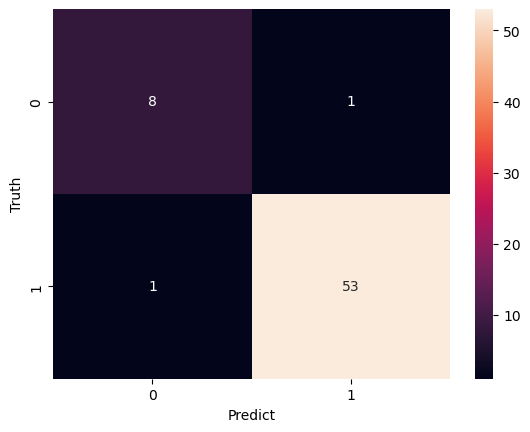

In [29]:
y_predicted = reg.predict(x_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_predicted)
import seaborn as sns
sns.heatmap(cm,annot = True)
plt.xlabel("Predict")
plt.ylabel("Truth")

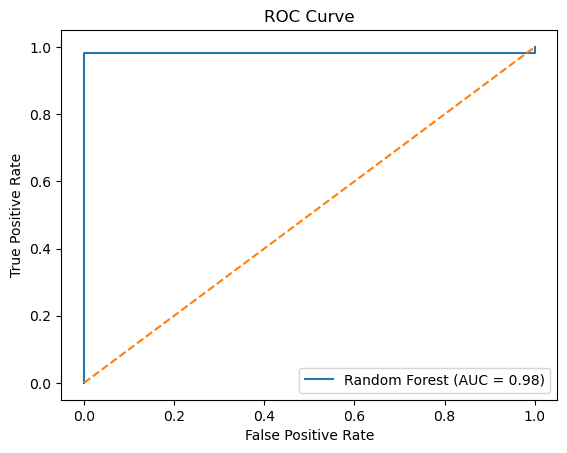

AUC: 0.9814814814814815


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_lg = reg.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lg)
auc_lg = roc_auc_score(y_test, y_prob_lg)

plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % auc_lg)
plt.plot([0,1], [0,1], linestyle="--")  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("AUC:", auc_lg)

## Decision Tree Trial

In [31]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(max_depth=4, random_state=42)

In [32]:
model_dt.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [33]:
dec_score = model_dt.score(x_test, y_test)
dec_score

0.9682539682539683

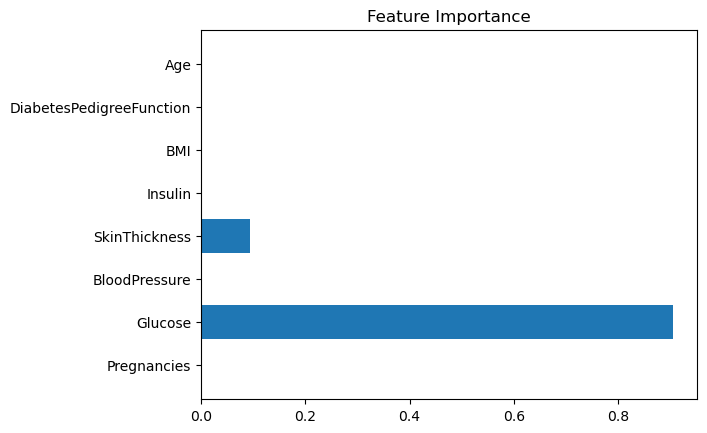

In [34]:
importances = model_dt.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

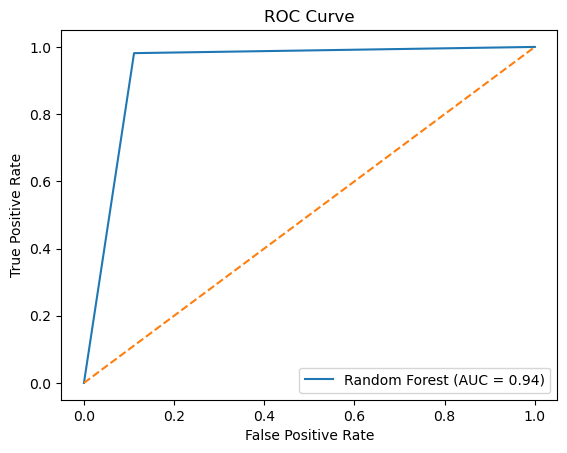

AUC: 0.9351851851851851


In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_dt = model_dt.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)
auc = roc_auc_score(y_test, y_prob_dt)

plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % auc)
plt.plot([0,1], [0,1], linestyle="--")  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("AUC:", auc)

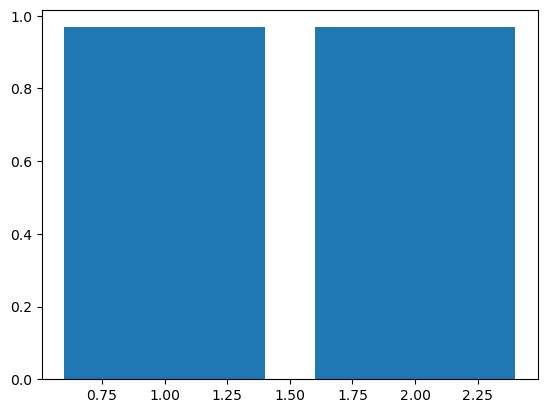

In [36]:
plt.bar([1,2],[log_score,dec_score])
plt.show()

# Random Forest Trial


In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
model2 = RandomForestClassifier(n_estimators = 400)
model2.fit(x_train,y_train)

RandomForestClassifier(n_estimators=400)

In [39]:
model2.score(x_test, y_test)

0.9841269841269841

In [40]:
y_pred = model2.predict(x_test)

In [41]:
rnd_score = model2.score(x_test, y_test)

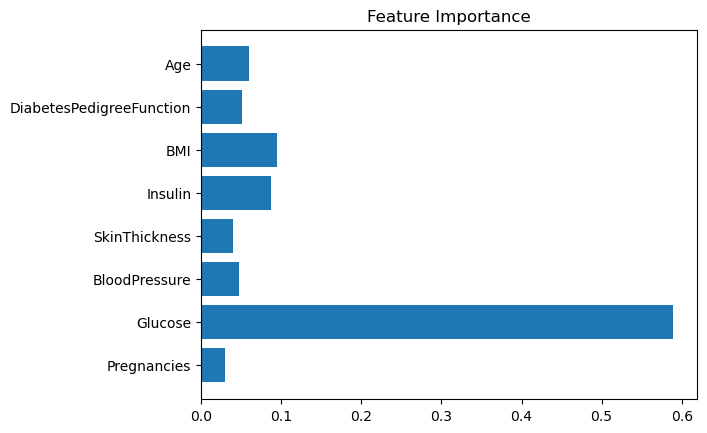

In [42]:
importances = model2.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

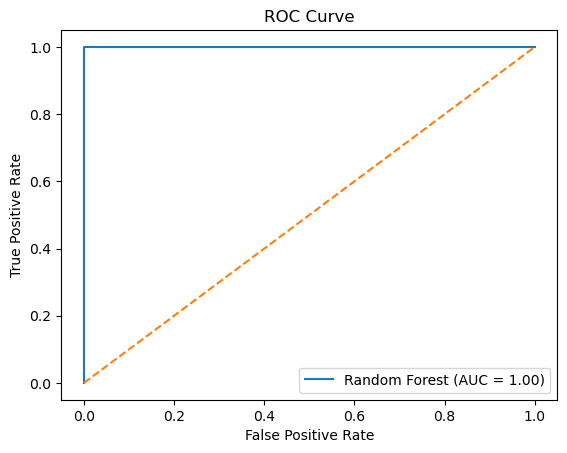

AUC: 1.0


In [43]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_rnd = model2.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rnd)
auc_rnd = roc_auc_score(y_test, y_prob_rnd)

plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % auc_rnd)
plt.plot([0,1], [0,1], linestyle="--")  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("AUC:", auc_rnd)

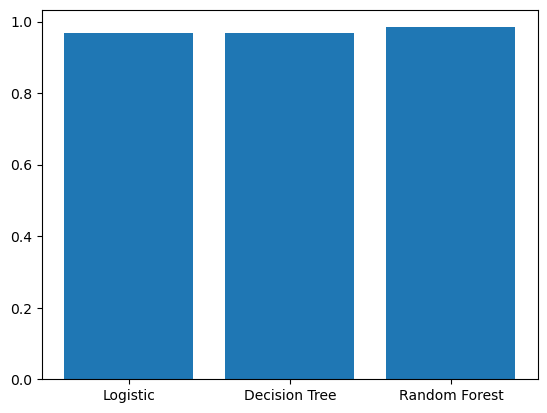

In [44]:
plt.bar(["Logistic","Decision Tree","Random Forest"],[log_score,dec_score, rnd_score])
plt.show()

# Support Vector Machine Trial

In [45]:
from sklearn.svm import SVC

In [65]:
model3 = SVC(C=8, kernel = "rbf", probability = True)
model3.fit(x_train, y_train)

SVC(C=8, probability=True)

In [66]:
svc_score = model3.score(x_test, y_test)
svc_score

0.9841269841269841

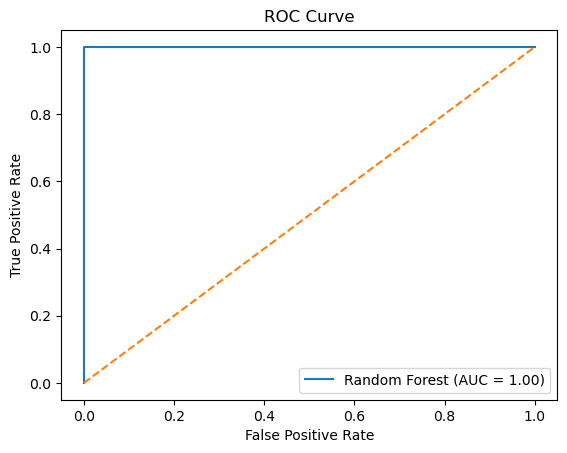

AUC: 1.0


In [67]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_svm = model3.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % auc_svm)
plt.plot([0,1], [0,1], linestyle="--")  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("AUC:", auc_svm)

## Model Comparison

After training multiple models, we compare their performance based on accuracy.

The comparison helps determine which model performs best for predicting diabetes.

In many cases, **ensemble models such as Random Forest perform better because they combine predictions from multiple decision trees.**

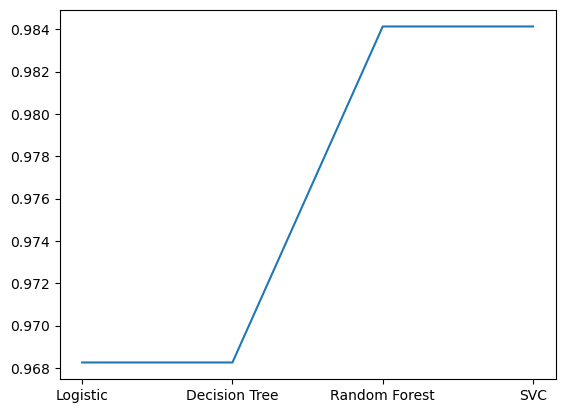

In [68]:
plt.plot(["Logistic","Decision Tree","Random Forest","SVC"],[log_score,dec_score, rnd_score,svc_score])
plt.show()

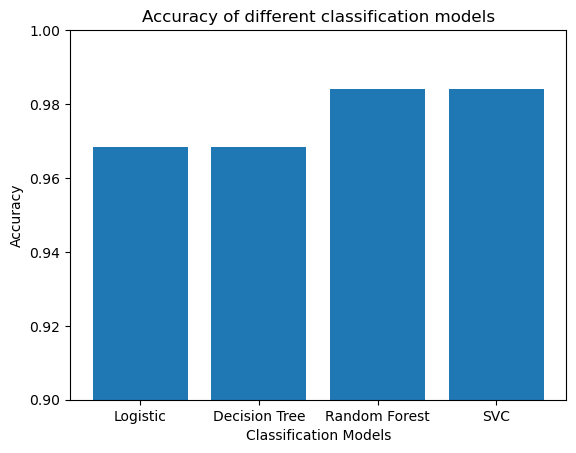

<Figure size 2000x1500 with 0 Axes>

In [69]:
plt.bar(["Logistic","Decision Tree","Random Forest","SVC"],[log_score,dec_score, rnd_score,svc_score])
plt.xlabel("Classification Models")
plt.ylabel("Accuracy")
plt.title("Accuracy of different classification models")
plt.ylim(0.9,1)
plt.figure(figsize = (20,15))
plt.show()

In [70]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM"],
    "Accuracy": [log_score, dec_score, rnd_score, svc_score]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.984127
3,SVM,0.984127
0,Logistic Regression,0.968254
1,Decision Tree,0.968254


## Hyperparameter Tuning

Machine learning models have parameters that control how the model learns from the data. 
These parameters are called **hyperparameters**.

To find the best combination of hyperparameters, we use **GridSearchCV**, which performs 
an exhaustive search over a specified parameter grid using cross-validation.

In this project, hyperparameter tuning is performed for the following models:

- Random Forest
- Support Vector Machine
- Decision Tree
- Logistic Regression

This helps improve model performance and ensures the models are optimized for the dataset.

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring="accuracy")

rf_grid.fit(x_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9839183673469387


In [55]:
best_rf = rf_grid.best_estimator_

In [56]:
from sklearn.svm import SVC

svm = SVC()

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring="accuracy")

svm_grid.fit(x_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best Score:", svm_grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.9757551020408162


In [57]:
best_svm = svm_grid.best_estimator_

In [58]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt_params = {
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring="accuracy")

dt_grid.fit(x_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best Score:", dt_grid.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best Score: 0.992


In [59]:
best_dt = dt_grid.best_estimator_

In [60]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring="accuracy")

lr_grid.fit(x_train, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best Score:", lr_grid.best_score_)

Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Best Score: 0.9758367346938777


In [61]:
best_lr = lr_grid.best_estimator_

In [62]:
from sklearn.metrics import accuracy_score

models = {
    "Random Forest": best_rf,
    "SVM": best_svm,
    "Decision Tree": best_dt,
    "Logistic Regression": best_lr
}

for name, model in models.items():
    y_pred = model.predict(x_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.9841269841269841
SVM Accuracy: 0.9682539682539683
Decision Tree Accuracy: 0.9682539682539683
Logistic Regression Accuracy: 0.9682539682539683


## Model Saving

After training and tuning the models, the final trained models are saved to disk using the pickle library.

Saving models allows us to reuse them later without retraining. 
This is useful for deploying machine learning models in real-world applications such as web apps or APIs.

Each trained model is stored as a `.pkl` file and can be loaded later for prediction.

In [52]:
import pickle
pickle.dump(reg, open("logistic_regression_model.pkl", "wb"))

pickle.dump(model_dt, open("decision_tree_model.pkl", "wb"))

pickle.dump(model2, open("random_forest_model.pkl", "wb"))

pickle.dump(model3, open("svm_model.pkl", "wb"))

# Conclusion

In [73]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM"],
    "Accuracy": [log_score, dec_score, rnd_score, svc_score]
})
print("Final Accuracies acheived for the four models")
results.sort_values(by="Accuracy", ascending=False)

Final Accuracies acheived for the four models


,Model,Accuracy
2,Random Forest,0.984127
3,SVM,0.984127
0,Logistic Regression,0.968254
1,Decision Tree,0.968254


## Conclusion

In this project, we developed a machine learning system to predict whether a person is likely to have diabetes using the **Pima Indians Diabetes Dataset**.

### Project Workflow

The project followed a complete machine learning pipeline:

1. **Data Loading and Exploration**
   The dataset was loaded and explored to understand its structure, features, and target variable.

2. **Data Cleaning**
   Some medical attributes contained unrealistic values such as 0 for glucose, blood pressure, insulin, BMI, and skin thickness.
   These values were treated as missing values and replaced with appropriate statistical values to improve data quality.

3. **Exploratory Data Analysis (EDA)**
   Various visualizations and statistical summaries were used to understand the distribution of features and relationships between variables.

4. **Feature Scaling**
   Since machine learning algorithms perform better when features are on a similar scale, the features were standardized using a scaler.

5. **Train–Test Split**
   The dataset was divided into training and testing sets so that the models could be evaluated on unseen data.

6. **Model Training**
   Four different machine learning models were trained for the classification task:

   * Logistic Regression
   * Decision Tree
   * Random Forest
   * Support Vector Machine (SVM)

7. **Model Evaluation**
   The models were evaluated using accuracy and other classification metrics to measure how well they predicted diabetes cases.

8. **Hyperparameter Tuning**
   To improve performance, hyperparameter tuning was performed using GridSearchCV with cross-validation.
   This helped identify the optimal parameters for each model.

9. **Model Comparison**
   The performance of the models was compared before and after hyperparameter tuning to determine which model performed best on the dataset.

10. **Model Saving**
    The final trained models and preprocessing components were saved using pickle so that they can be reused later without retraining.

### Final Outcome

Among the models tested, the tuned models achieved improved performance compared to their default versions but when tested on the test data performed similar to the default version while SVM performed little below the default version. Ensemble methods such as Random Forest generally perform well because they combine multiple decision trees to produce more stable predictions. **Random Forest and Support Vector Machine** performed best for the test data.

### Future Improvements

Possible improvements to this project include:

* Training on larger and more diverse medical datasets
* Applying advanced models such as Gradient Boosting or XGBoost
* Building a web application for real-time diabetes prediction
* Performing deeper feature engineering and model interpretability analysis

Overall, this project demonstrates the **end-to-end workflow of a machine learning classification problem**, including data preprocessing, model training, evaluation, optimization, and model deployment preparation.
